In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ODE
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Forward Euler function
def forward_euler(f, y0, x0, xf, h):
    x_values = np.arange(x0, xf + h, h, dtype=float)
    y_values = np.zeros_like(x_values, dtype=float)
    y_values[0] = y0

    for i in range(len(x_values) - 1):
        y_values[i+1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values


In [2]:
# Parameters
x0 = 0
xf = 10 * np.pi
y0 = 1

h_values = [0.01, 0.05] + list(np.arange(0.15, 1.0, 0.05))

# fine exact curve for plotting
x_fine = np.linspace(x0, xf, 5000)
y_fine = y_exact(x_fine)

# store results
avg_y_list = []
avg_error_list = []
local_error_list = []
y_at_15_list = []


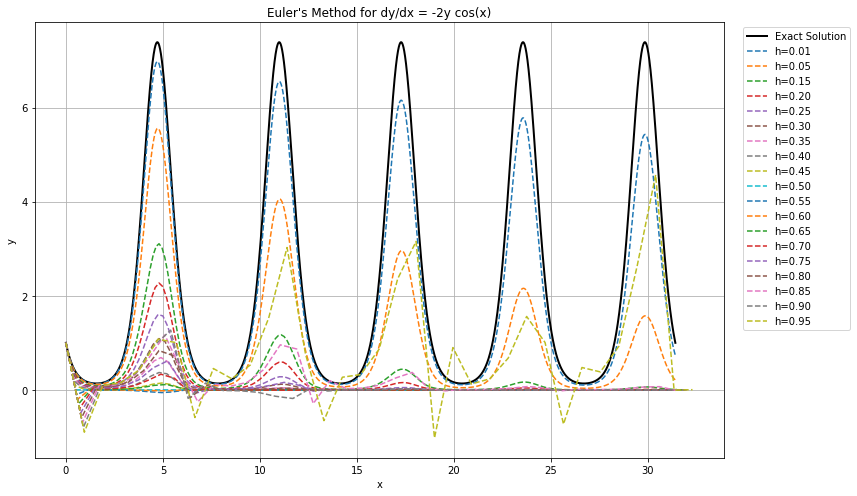

In [3]:
plt.figure(figsize=(12, 7))
plt.plot(x_fine, y_fine, 'k', linewidth=2, label='Exact Solution')

for h in h_values:
    x_num, y_num = forward_euler(f, y0, x0, xf, h)

    # exact values at the same x grid as Euler
    y_true = y_exact(x_num)

    # average y-value for this run
    avg_y = np.mean(y_num)
    avg_y_list.append(avg_y)

    # average error over the whole run
    avg_error = np.mean(np.abs(y_num - y_true))
    avg_error_list.append(avg_error)

    # value near x = 15
    idx_15 = np.argmin(np.abs(x_num - 15))
    x_near_15 = x_num[idx_15]
    y_near_15 = y_num[idx_15]
    y_true_15 = y_exact(x_near_15)

    y_at_15_list.append((h, x_near_15, y_near_15, y_true_15))

    # local error near x ≈ 15
    local_error = abs(y_near_15 - y_true_15)
    local_error_list.append(local_error)

    plt.plot(x_num, y_num, '--', label=f'h={h:.2f}')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y cos(x)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

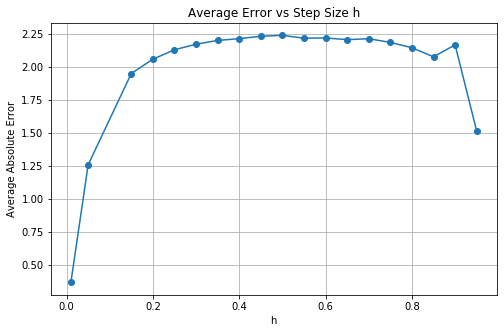

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_error_list, 'o-')
plt.xlabel('h')
plt.ylabel('Average Absolute Error')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.show()


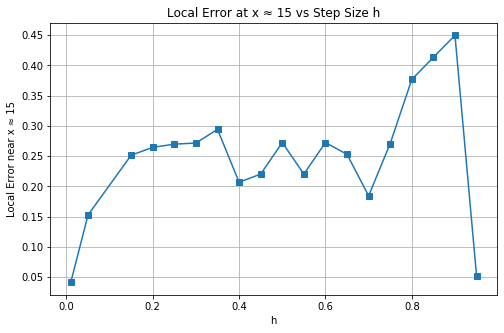

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_error_list, 's-')
plt.xlabel('h')
plt.ylabel('Local Error near x ≈ 15')
plt.title('Local Error at x ≈ 15 vs Step Size h')
plt.grid(True)
plt.show()

In [6]:
print("h\tavg(y)\t\tavg error\tlocal error near x≈15")
for i, h in enumerate(h_values):
    print(f"{h:.2f}\t{avg_y_list[i]:.6f}\t{avg_error_list[i]:.6f}\t{local_error_list[i]:.6f}")

print("\nValues near x ≈ 15:")
print("h\tx_used\t\ty_Euler\t\t y_exact")
for h, x_used, y_num_15, y_true_15 in y_at_15_list:
    print(f"{h:.2f}\t{x_used:.6f}\t{y_num_15:.6f}\t{y_true_15:.6f}")

h	avg(y)		avg error	local error near x≈15
0.01	1.910450	0.368561	0.040935
0.05	1.017291	1.258792	0.152506
0.15	0.319016	1.950547	0.251454
0.20	0.203286	2.059003	0.264472
0.25	0.135263	2.130091	0.269713
0.30	0.090738	2.172528	0.271622
0.35	0.060342	2.200846	0.294172
0.40	0.039020	2.214620	0.206679
0.45	0.024619	2.232445	0.220242
0.50	0.015625	2.239393	0.272375
0.55	0.011765	2.217616	0.220243
0.60	0.013616	2.219700	0.272375
0.65	0.021267	2.206864	0.252852
0.70	0.033042	2.213891	0.184239
0.75	0.058823	2.186116	0.270801
0.80	0.066797	2.145726	0.376756
0.85	0.167741	2.077047	0.413405
0.90	0.071732	2.167421	0.449745
0.95	0.767397	1.514540	0.051873

Values near x ≈ 15:
h	x_used		y_Euler		 y_exact
0.01	15.000000	0.231440	0.272375
0.05	15.000000	0.119869	0.272375
0.15	15.000000	0.020921	0.272375
0.20	15.000000	0.007903	0.272375
0.25	15.000000	0.002662	0.272375
0.30	15.000000	0.000753	0.272375
0.35	15.050000	0.000170	0.294342
0.40	14.800000	0.000018	0.206696
0.45	14.850000	0.000001	0.220243
0.50

We can observe how as step size increases, oscillations get bigger. When the step size is smaller, Euler's method is more accurate, and becomes less accurate as step size increases. This is because error begins accumulating, and as a result the average and local error increase for larger values of h.

#### OpenAI. (2026). ChatGPT (GPT-5.3) Prompted ChatGPT to assist with calculating local error and average error and debug some plotting mistakes.